In [5]:
from Calibration import *
from Integrate_and_save import *
import tkinter as tk
from tkinter import filedialog
import os
import pyFAI
pyFAI.use_opencl = False

root = tk.Tk()
root.withdraw()  # Hide the root window
root.attributes("-topmost", True)  # Keep the dialog on top

''

In [15]:
calibrant = 'ito_calibrant.D'
ponifile = 'ITO_test.poni'

giwaxsCalibration(ponifile, calibrant)

Launching pyFAI calibration GUI. This will take a few seconds...


In [15]:
ITO_image_path = filedialog.askopenfilename(
    title="Select the ITO image",
    filetypes=[("All files", "*.*")]
)


K:/MAPbI3_nanofibers_S1__refined.poni
Detector Pilatus 1M	 PixelSize= 172µm, 172µm	 BottomRight (3)
Wavelength= 1.239842e-10 m
SampleDetDist= 1.953819e-01 m	PONI= 8.785969e-02, 4.548021e-02 m	rot1=-0.644276  rot2=0.013080  rot3=3.141593 rad
DirectBeamDist= 244.390 mm	Center: x=1117.752, y=529.396 pix	Tilt= 36.921° tiltPlanRotation= 1.248° 𝛌= 1.240Å


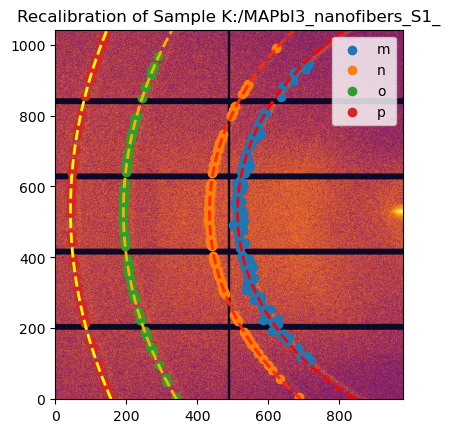

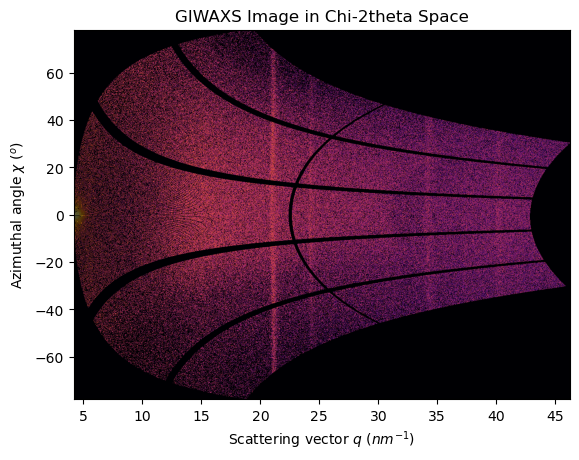

In [16]:




image_path = ITO_image_path
sample_name = image_path.split("\\")[-1].split(".")[0]  # Extract sample name from image path
initial_poni = r"nanofibers_init.poni"
calibrant_file = r"ito_calibrant_refine.D"

if not image_path.endswith(".tif"):
    refined_poni = image_path + "_refined.poni"
else:
    refined_poni = image_path.replace(".tif", "_refined.poni")
print(refined_poni)
refine_calibration(sample_name, image_path, initial_poni, calibrant_file, refined_poni)
plot_Chi_2theta(image_path, refined_poni) #sanity check, the lines should be straight and vertical

In [17]:
folder_path = filedialog.askdirectory(
    title="Select the folder with images to integrate",
    mustexist=True
)

Integrating TIFs: 100%|██████████| 821/821 [00:22<00:00, 36.34it/s]


Saved integrated GIWAXS data to K:/MAPbI3_nanofibers_S1__GIWAXS_raw.npz


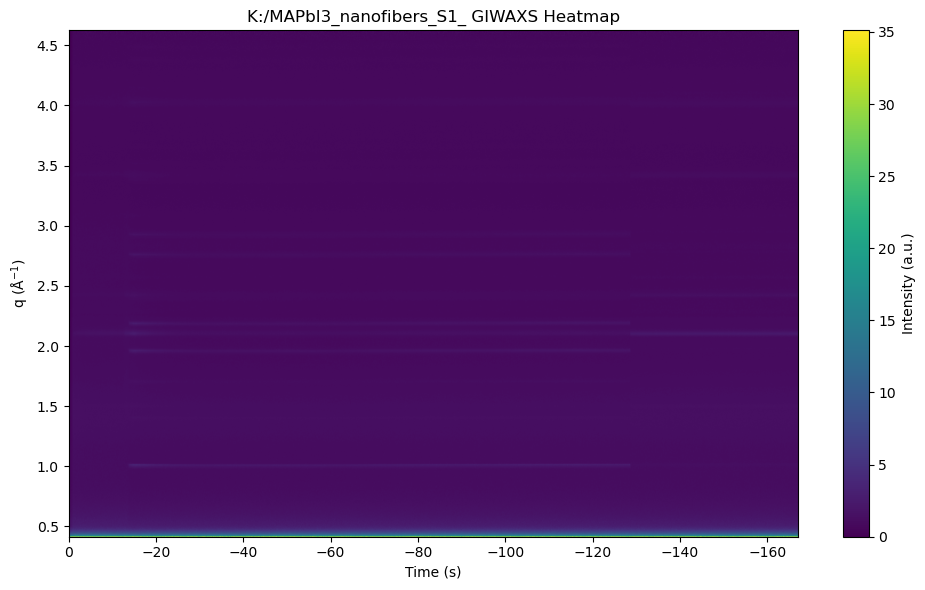

<Figure size 640x480 with 0 Axes>

In [18]:


# folder_path  = r'k:\printz_Apr2024\MAPI_YL\MAPI_1pct_AVACl_S1_18_5min'
# # Integrate the refined calibration
method = ("full", "csr", "opencl")
integrated_data = integrate_giwaxs(folder_path, refined_poni, method)
#if you don't have a GPU or don't want to use opencl, you can use the following line instead:
# integrated_data = integrate_giwaxs(folder_path, refined_poni)
save_and_plot(*integrated_data, folder_path, sample_name)

<>:14: SyntaxWarning: invalid escape sequence '\M'
<>:14: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Aj\AppData\Local\Temp\ipykernel_36368\581425105.py:14: SyntaxWarning: invalid escape sequence '\M'
  q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")


[0.41496684 0.41918049 0.42339415 0.4276078  0.43182146 0.43603511
 0.44024877 0.44446242 0.44867608 0.45288974 0.45710339 0.46131705
 0.4655307  0.46974436 0.47395801 0.47817167 0.48238532 0.48659898
 0.49081264 0.49502629 0.49923995 0.5034536  0.50766726 0.51188091
 0.51609457 0.52030822 0.52452188 0.52873553 0.53294919 0.53716285
 0.5413765  0.54559016 0.54980381 0.55401747 0.55823112 0.56244478
 0.56665843 0.57087209 0.57508575 0.5792994  0.58351306 0.58772671
 0.59194037 0.59615402 0.60036768 0.60458133 0.60879499 0.61300864
 0.6172223  0.62143596 0.62564961 0.62986327 0.63407692 0.63829058
 0.64250423 0.64671789 0.65093154 0.6551452  0.65935886 0.66357251
 0.66778617 0.67199982 0.67621348 0.68042713 0.68464079 0.68885444
 0.6930681  0.69728175 0.70149541 0.70570907 0.70992272 0.71413638
 0.71835003 0.72256369 0.72677734 0.730991   0.73520465 0.73941831
 0.74363197 0.74784562 0.75205928 0.75627293 0.76048659 0.76470024
 0.7689139  0.77312755 0.77734121 0.78155486 0.78576852 0.7899

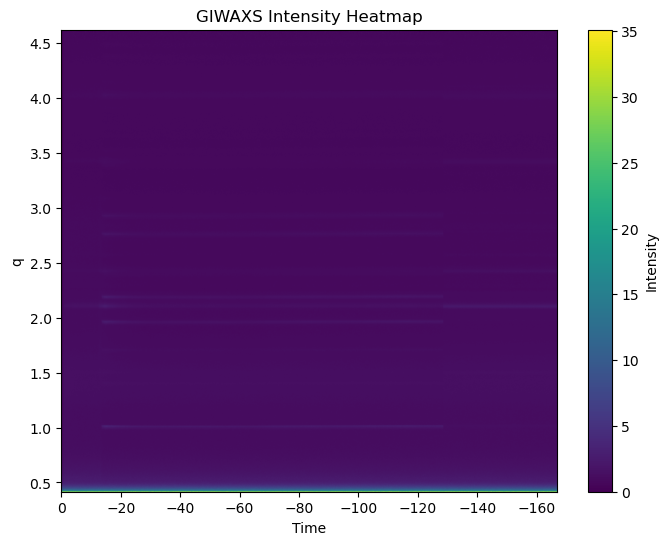

In [6]:
import glob
def load_GIWAXS_npz(npz_file_folder):
    """
    Load previously saved GIWAXS q, time, intensity arrays from .npz.
    """
    # Find the first .npz file in the folder
    npz_files = glob.glob(os.path.join(npz_file_folder, "*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No .npz files found in {npz_file_folder}")
    npz_file_path = npz_files[0]
    data = np.load(npz_file_path)
    return data["q"], data["time"], data["intensity"]

q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")
print(f"{q}, {time}, {intensity}")
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(intensity.T, aspect='auto', extent=[time[0], time[-1], q[0], q[-1]], origin='lower', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Time')
plt.ylabel('q')
plt.title('GIWAXS Intensity Heatmap')
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\M'
<>:42: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Aj\AppData\Local\Temp\ipykernel_36368\4047504471.py:42: SyntaxWarning: invalid escape sequence '\M'
  q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")


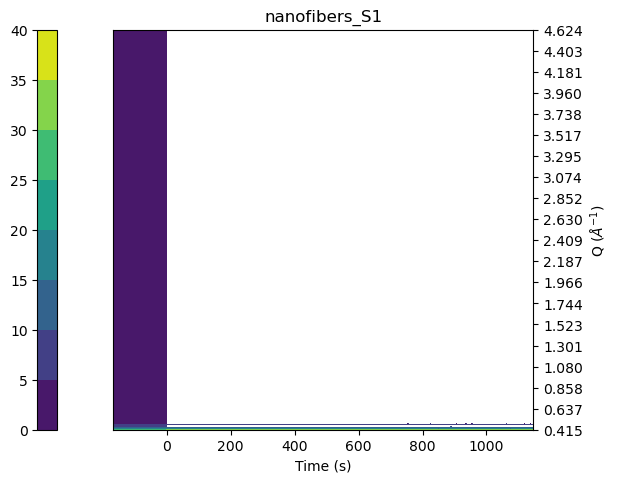

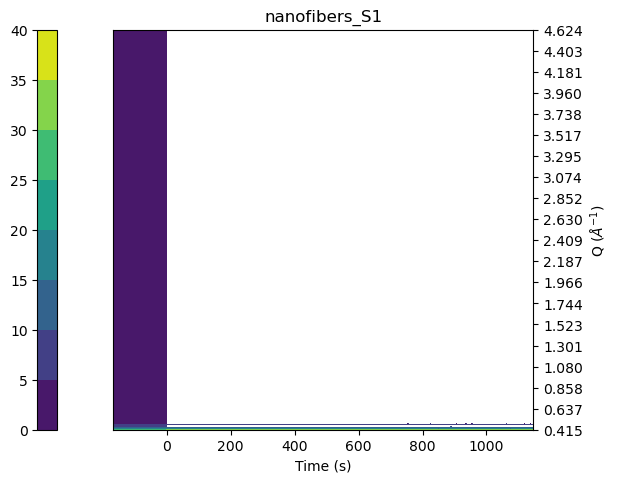

In [ ]:
def plotGIWAXS(sample_name, q, frame_time, intensity):

    '''
    Parameters
    ----------
    sample_name : str,
        name of the sample. Default is the name under which scan is saved.
    save_path : path object
        where the output is saved.


    Returns
    -------
    Contour plot

    '''

    # create an empty figure with the following dimensions
    fig = plt.figure(figsize=(7, 5))
    left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
    ax = fig.add_axes([left, bottom, width, height])

    # add the contour plot and a colorbar
    cp = ax.contourf(frame_time, q, intensity.T)
    plt.colorbar(cp, location='left')

    # define axis names, ticks, etc.
    q_min, q_max = (q[0], q[-1])
    y_ticks = np.linspace(q_min, q_max, 20)  # number of tickmarks
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(r'Q $(\AA^{-1})$')
    ax.set_yticks(y_ticks)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.set_ylim(q_min, q_max)
    ax.set_title(sample_name)
    # plt.show(block=False)
    # plt.pause(1)

    return fig
sample_name = "nanofibers_S1"
q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")
plotGIWAXS(sample_name, q, time, intensity)

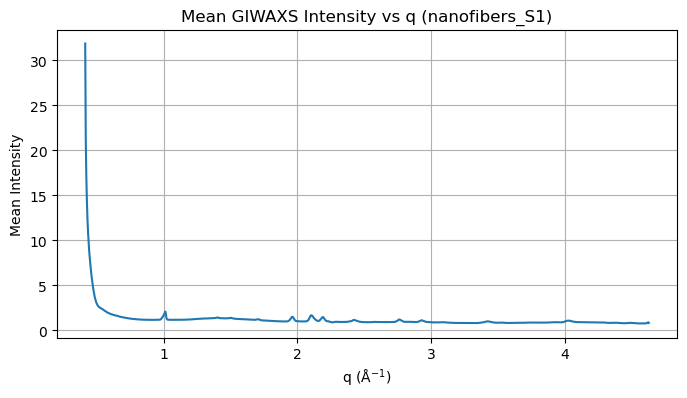

In [10]:
import matplotlib.pyplot as plt

mean_q_profile = np.mean(intensity, axis=0)

plt.figure(figsize=(8, 4))
plt.plot(q, mean_q_profile)
plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("Mean Intensity")
plt.title("Mean GIWAXS Intensity vs q (nanofibers_S1)")
plt.grid(True)
plt.show()
